In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv('Churn_Modelling.csv')

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [11]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [24]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

In [25]:
from sklearn.model_selection import train_test_split
X = df.drop('Exited', axis=1)
y = df['Exited']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
X_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(8000, 11))

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [55]:
model = Sequential()

model.add(Dense(8, activation='relu', input_dim = 11))
model.add(Dense(8, activation='relu', input_dim = 11))
model.add(Dense(1, activation='sigmoid'))

d:\whole ML\mlvenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177 (708.00 B)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [64]:
history = model.fit(X_train_scaled, y_train, epochs=40, validation_split=0.2)

Epoch 1/40
  1/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8125 - loss: 0.3680

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - accuracy: 0.8611 - loss: 0.3359 - val_accuracy: 0.8594 - val_loss: 0.3420
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - accuracy: 0.8623 - loss: 0.3355 - val_accuracy: 0.8606 - val_loss: 0.3431
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - accuracy: 0.8619 - loss: 0.3355 - val_accuracy: 0.8594 - val_loss: 0.3423
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step - accuracy: 0.8614 - loss: 0.3351 - val_accuracy: 0.8600 - val_loss: 0.3426
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step - accuracy: 0.8625 - loss: 0.3349 - val_accuracy: 0.8587 - val_loss: 0.3423
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - accuracy: 0.8611 - loss: 0.3347 - val_accuracy: 0.8562 - val_loss: 0.3422
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.8636 - loss: 0.3345 - val_accuracy: 0.8606 - val_loss: 0.3425
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - accuracy: 0.8617 - loss: 0.3342 - val_accurac

In [59]:
model.layers[0].get_weights()

[array([[ 0.08697088,  0.3517915 ,  0.29680237, -0.35306638,  0.02201351,
         -0.00904837,  0.01789956,  0.03437227],
        [-0.2468448 , -0.77664006, -0.679813  , -0.59452885, -1.0397596 ,
         -0.01148644,  0.36481583,  0.20238164],
        [ 0.15088853, -0.02310724, -0.37804887,  0.18731588, -0.08474193,
         -0.06736179,  0.12589227, -0.01627723],
        [ 0.16656655,  0.44161013, -0.5325179 , -0.2987638 ,  0.21131   ,
          0.47811466,  0.25948432,  0.03521661],
        [ 1.3573507 , -0.2455419 ,  0.4618984 ,  0.3091844 ,  0.19109665,
          1.2479804 ,  0.02156496, -0.8911481 ],
        [-0.19269072,  0.4094546 , -0.27410728,  0.11347642, -0.2244955 ,
          0.03420757,  0.24156952, -0.07673743],
        [ 0.23967722, -0.5002289 , -0.06339471, -0.31782076, -0.42625284,
         -0.18008572,  1.0091262 , -0.4812394 ],
        [-0.09674329,  0.06606214,  0.4626758 , -0.62128025,  0.09123179,
          0.03348893,  0.08487303,  0.07703626],
        [-0.4563

In [60]:
model.layers[1].get_weights()


[array([[-0.5920797 ,  0.8242478 ,  0.4720292 , -0.20508948,  0.2635267 ,
         -0.36852032,  0.2856319 , -0.6028025 ],
        [-0.28160173,  0.2977013 , -0.5975132 ,  0.8041068 , -0.7752933 ,
         -0.00996175, -0.330733  ,  0.34754038],
        [ 0.3242894 ,  0.27086052,  0.06355215,  0.67508143, -0.2880667 ,
         -0.26488537,  0.430231  ,  0.46894202],
        [ 0.24106747, -0.2443964 , -0.3577476 ,  0.39638916, -0.05073842,
         -0.14974695,  0.5538005 , -0.20990472],
        [-0.7412808 , -0.31481603,  0.06962955,  0.82111967, -0.5540579 ,
         -0.4132033 ,  0.3672612 , -0.33747327],
        [-0.12247365, -1.074227  ,  0.87415195,  0.16165954,  0.59082127,
         -0.02961509, -0.4926005 , -0.69319546],
        [-0.05864148, -0.2016158 , -0.21878968,  0.64902556, -0.5404369 ,
         -0.41872436,  0.77060276, -0.33656344],
        [ 0.46195275, -0.08563814, -1.0213157 ,  0.06151582,  0.45571873,
         -0.5818362 ,  0.07847475,  0.42607108]], dtype=float32),

In [61]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step


In [62]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [63]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
acc

0.8565

In [65]:
import matplotlib.pyplot as plt

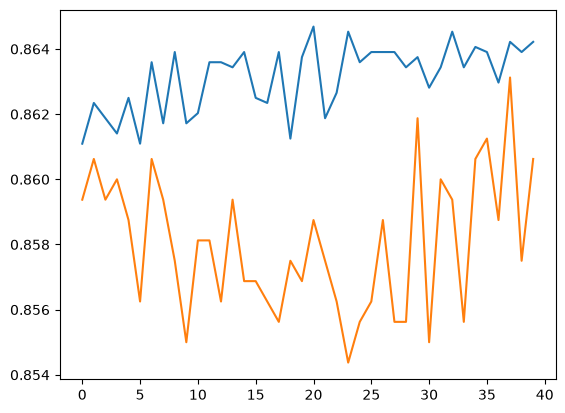

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'], )

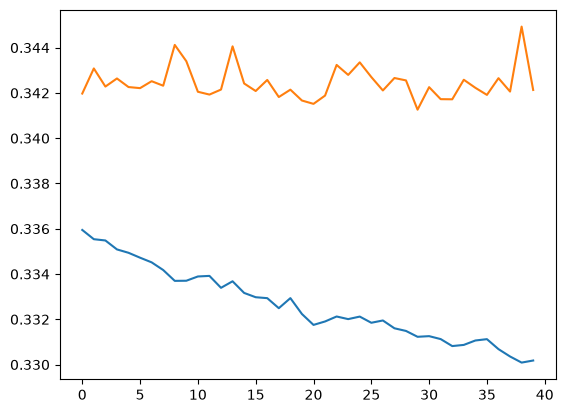

In [69]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')